<a href="https://colab.research.google.com/github/BandanaSingha24/AI-ML-DL-in-Cancer-Genomics/blob/main/03_Machine_Learning_Essential_for_Bioinformati/02.%20TCGA_BRCA_in_Unsupervised_ML_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Step 1: Data Loading and Preparation
df = pd.read_csv("data.csv")

# Extracting the features
X = df.values

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data successfully scaled!")
print("Shape of scaled data:", X_scaled.shape)


Data successfully scaled!
Shape of scaled data: (705, 1937)


In [2]:
# Step 2: Dimentionality Reduction(Principal Component Analysis)

from sklearn.decomposition import PCA

# Yahan hum 1937 dimensions ko kam karke 2 main components mein la rahe hain
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# PCA ke result ko ek naye dataframe mein store karna
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

print("PCA transformation complete!")
print("New shape of data:", pca_df.shape)


PCA transformation complete!
New shape of data: (705, 2)


In [3]:
# Step 3: K-Means Clustering
# Is step mein hum machine ko keh rahe hain ki woh PCA se mile hue
# 2D points ko unki similarity ke hisaab se 2 alag-alag groups (clusters) mein baant de.

from sklearn.cluster import KMeans

# KMeans algorithm ko initialize karna (2 clusters ke liye)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(pca_df)

# Clustering ke result ko humare 'pca_df' dataframe mein ek naye column ki tarah jodna
pca_df['Cluster'] = clusters

print("Clustering complete!")

Clustering complete!


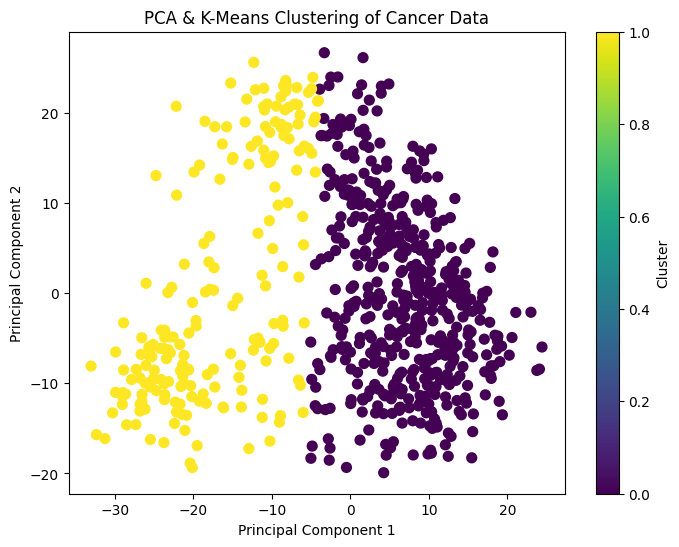

In [4]:
# Step 4: Visualizing the Clusters

# Is step mein hum matplotlib ka use karke ek graph banayenge
# jisse hum dekh sakein ki hamara data 2 clusters mein kaise divide hua hai.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Dono clusters ko plot karna
# c=pca_df['Cluster'] ka matlab hai ki clusters ke hisaab se color change hoga
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='viridis', s=50)

plt.title('PCA & K-Means Clustering of Cancer Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()


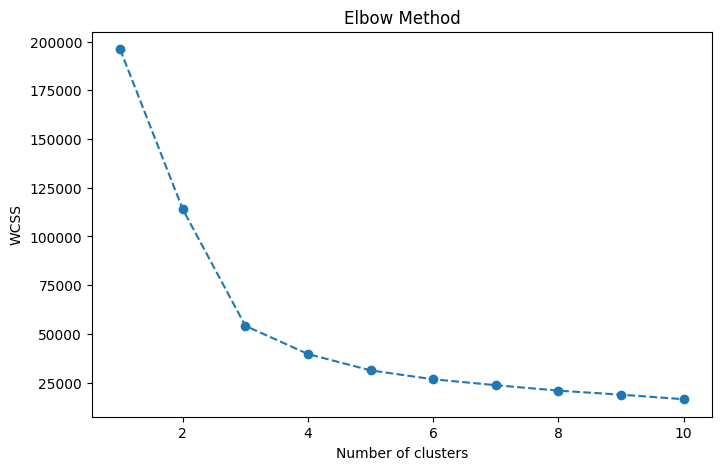

In [5]:
# Step 5: Elbow Method

# Is step mein hum wcss (Within-Cluster Sum of Square) calculate kar rahe hain,
# jisse humein pata chalega ki kitne clusters sabse best rahenge.

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(pca_df[['PC1', 'PC2']])
    wcss.append(kmeans.inertia_)

# Elbow Graph plot karna
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


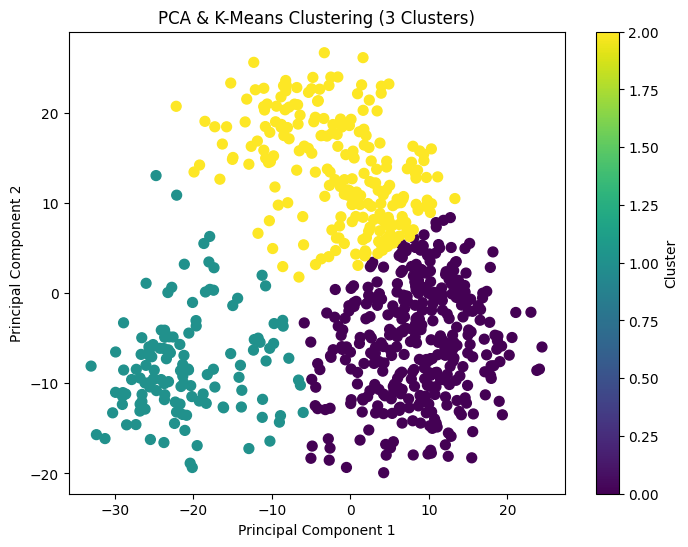

In [6]:
# Step 6: Visualizing with 3 Clusters

# Hum n_clusters ko 3 kar rahe hain kyunki Elbow graph wahi bend ho raha hai.

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 3 clusters ke saath model ko fit karna
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_df[['PC1', 'PC2']])

# Naye cluster labels ko dataframe mein update karna
pca_df['Cluster'] = clusters

# Ab 3 clusters ke saath graph plot karna
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='viridis', s=50)
plt.title('PCA & K-Means Clustering (3 Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

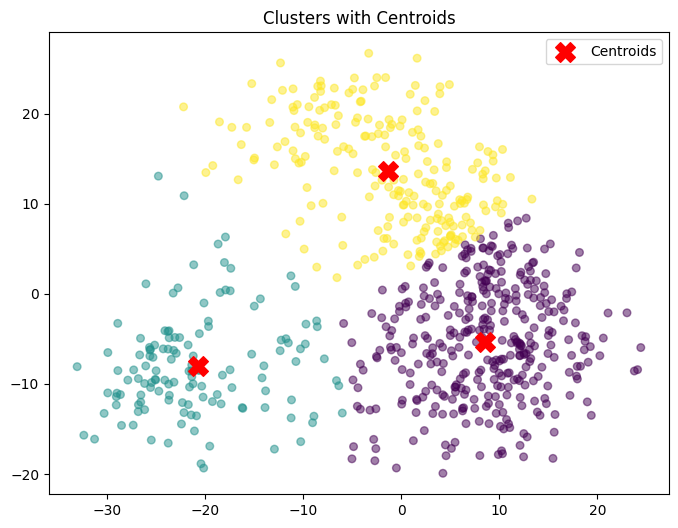

In [7]:
# Step 7: Analyzing Cluster Centers
# Is step mein hum dekhenge ki har cluster ka 'center' kahan hai,
# taaki hum samajh sakein ki clusters ek-dusre se kitne door hain.

# Centers nikalna
centers = kmeans.cluster_centers_

# Plotting the centers
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='viridis', s=30, alpha=0.5)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title('Clusters with Centroids')
plt.legend()
plt.show()


In [8]:
# Step 8: Finding Important Genes

# Is step mein hum PCA ke 'loadings' ko check karenge.
# PCA ke components mein kin genes ka weight sabse zyada hai, wahi hamare important genes hain.

import numpy as np

# PCA ke components (loadings) ko nikalna
loadings = pca.components_

# Sabse zyada asar daalne wale genes dhoondhna
# PC1 ke liye top 5 genes
n_genes = 5
top_genes_indices = np.argsort(np.abs(loadings[0]))[-n_genes:][::-1]

# Feature names (Genes ke naam)
feature_names = df.columns
print("Top 5 most important genes that define the difference between clusters:")
for i in top_genes_indices:
    print(f"- {feature_names[i]}")

Top 5 most important genes that define the difference between clusters:
- rs_ESR1
- rs_FOXA1
- rs_AGR3
- rs_VGLL1
- rs_ROPN1
